# Predicting Customer Churn
**`Playground Series - Season 6 Episode 3`**

**GOAL:** Predict the likelihood of customer churn.

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

sys.path.append(os.path.abspath(".."))

In [3]:
# Import custom modules
from Scripts.plot_charts import (
    plot_bar_counts, plot_bar_percentages,
    plot_hist_counts, plot_hist_percentages,
    plot_box_by_target,
    plot_stacked_bar_by_target, plot_grouped_bar_by_target
)

In [4]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve

import optuna
from optuna.samplers import TPESampler

import catboost as cb
import xgboost as xgb
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

D:\Anaconda\envs\dataScience\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
start_time = datetime.datetime.now()

## Read Dataset

In [6]:
train_df = pd.read_csv("../Data/train.csv")
test_df = pd.read_csv("../Data/test.csv")

In [7]:
numerical_features = ['TENURE', 'MONTHLY_CHARGES']

## Preprocessing

In [8]:
def preprocess_and_engineer_Feature(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    
    # Make a copy of dataframe
    dataframe = dataframe.copy()

    # Standardize columns
    dataframe.columns = [
        col.upper() for col in dataframe.columns
    ]

    column_change_dict = {
        "SENIORCITIZEN": "SENIOR_CITIZEN",
        "PHONESERVICE": "PHONE_SERVICE",
        "MULTIPLELINES": "MULTIPLE_LINES",
        "INTERNETSERVICE": "INTERNET_SERVICE",
        "ONLINESECURITY": "ONLINE_SECURITY",
        "ONLINEBACKUP": "ONLINE_BACKUP",
        "DEVICEPROTECTION": "DEVICE_PROTECTION",
        "TECHSUPPORT": "TECH_SUPPORT",
        "STREAMINGTV": "STREAMING_TV",
        "STREAMINGMOVIES": "STREAMING_MOVIES",
        "PAPERLESSBILLING": "PAPERLESS_BILLING",
        "PAYMENTMETHOD": "PAYMENT_METHOD",
        "MONTHLYCHARGES": "MONTHLY_CHARGES",
        "TOTALCHARGES": "TOTAL_CHARGES"
    }

    dataframe.rename(
        columns = column_change_dict, inplace = True
    )

    # Drop Columns
    columns_to_drop = [
        'ID', 'PAYMENT_METHOD',
        'CONTRACT_MM', 'CONTRACT_OY', 'CONTRACT_TY', 'INTERNET_SERVICE_DSL', 'INTERNET_SERVICE_FO', 'TENURE_GROUP', 'IS_ECHEQUE'
    ]

    # Encoding
    dataframe['GENDER'] = dataframe['GENDER'].map({'Female': 0, 'Male': 1})
    dataframe['PARTNER'] = dataframe['PARTNER'].map({'No': 0, 'Yes': 1})
    dataframe['DEPENDENTS'] = dataframe['DEPENDENTS'].map({'No': 0, 'Yes': 1})
    dataframe['PHONE_SERVICE'] = dataframe['PHONE_SERVICE'].map({'No': 0, 'Yes': 1})
    dataframe['MULTIPLE_LINES'] = dataframe['MULTIPLE_LINES'].map({'No': 0, 'No phone service': -1, 'Yes': 1})
    dataframe['INTERNET_SERVICE'] = dataframe['INTERNET_SERVICE'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
    dataframe['ONLINE_SECURITY'] = dataframe['ONLINE_SECURITY'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['ONLINE_BACKUP'] = dataframe['ONLINE_BACKUP'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['DEVICE_PROTECTION'] = dataframe['DEVICE_PROTECTION'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['TECH_SUPPORT'] = dataframe['TECH_SUPPORT'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['STREAMING_TV'] = dataframe['STREAMING_TV'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['STREAMING_MOVIES'] = dataframe['STREAMING_MOVIES'].map({'No': 0, 'No internet service': -1, 'Yes': 1})
    dataframe['CONTRACT'] = dataframe['CONTRACT'].map({'Month-to-month': -1, 'One year': 0, 'Two year': 1})
    dataframe['PAPERLESS_BILLING'] = dataframe['PAPERLESS_BILLING'].map({'No': 0, 'Yes': 1})

    # --------------------------------------- Feature Engineering ---------------------------------------
    # Actual Total Charges incured
    dataframe['ACT_TOTAL_CHARGES'] = dataframe['TENURE'] * dataframe['MONTHLY_CHARGES']

    # TC_RATIO - How much they actually paid vs expected
    dataframe['CHARGES_PAID_RATIO'] = dataframe['TOTAL_CHARGES'] / dataframe['ACT_TOTAL_CHARGES']

    # Average monthly spend over entire tenure
    dataframe['AVG_MONTLY_CHARGES'] = dataframe['TOTAL_CHARGES'] / dataframe['TENURE']

    # Type of Internet Services
    dataframe['INTERNET_SERVICE_DSL'] = (dataframe['INTERNET_SERVICE'] == 1).astype(int)
    dataframe['INTERNET_SERVICE_FO'] = (dataframe['INTERNET_SERVICE'] == 2).astype(int)

    # Number of Streaming Services
    dataframe['IS_STREAMING_ANYTHING'] = (
        (dataframe['STREAMING_MOVIES'] == 1) | (dataframe['STREAMING_TV'] == 1)
    ).astype(int)
    
    dataframe['NUM_STREAMING_SERVICES'] = (
        (dataframe[['STREAMING_MOVIES', 'STREAMING_TV']] == 1)
    ).sum(axis = 1)
    
    # Tenure buckets — tree models can miss these boundaries
    dataframe['TENURE_GROUP'] = pd.cut(
        dataframe['TENURE'],
        bins = [0, 12, 24, 48, 72],
        labels = [0, 1, 2, 3]
    ).astype(int)

    # Number of Additional Services
    dataframe['NUM_ADDITIONAL_SERVICES'] = (
        (dataframe[['ONLINE_SECURITY', 'ONLINE_BACKUP', 'DEVICE_PROTECTION', 'TECH_SUPPORT']] == 1)
    ).sum(axis = 1)

    # Total Number of Services
    dataframe['NUM_TOTAL_SERVICES'] = dataframe['NUM_STREAMING_SERVICES'] + dataframe['NUM_ADDITIONAL_SERVICES']

    # Contract New Columns
    dataframe['CONTRACT_MM'] = (dataframe['CONTRACT'] == -1).astype(int)
    dataframe['CONTRACT_OY'] = (dataframe['CONTRACT'] == 0).astype(int)
    dataframe['CONTRACT_TY'] = (dataframe['CONTRACT'] == 1).astype(int)

    # Payment Method
    dataframe['PAYMENT_METHOD'] = dataframe['PAYMENT_METHOD'].map(
        {'Bank transfer (automatic)': 'BT', 'Credit card (automatic)': 'CC', 'Electronic check': 'EC', 'Mailed check': 'MC'}
    )
    payment_dummies = pd.get_dummies(
        dataframe['PAYMENT_METHOD'], prefix = 'PAYMENT'
    ).astype(int)
    dataframe = pd.concat([dataframe, payment_dummies], axis=1)

    # Is Payment Automatic
    dataframe['IS_PAYMENT_AUTOMATIC'] = dataframe['PAYMENT_METHOD'].isin(
        ['BT', 'CC']
    ).astype(int)

    # Electronic check specifically correlates strongly with churn
    dataframe['IS_ECHEQUE'] = (dataframe['PAYMENT_METHOD'] == 'EC').astype(int)

    # Check if 'CHURN' is dataframe
    if('CHURN' in dataframe.columns):
        dataframe['CHURN'] = dataframe['CHURN'].map({'No': 0, 'Yes': 1})

    # Drop columns
    dropped_columns = [
        col for col in columns_to_drop if col in dataframe.columns
    ]
    
    dataframe = dataframe.drop(columns = dropped_columns)
    return dataframe

In [9]:
def split_features_and_target(
    dataframe: pd.DataFrame
) -> Tuple[pd.DataFrame, pd.Series]:
    if('CHURN' not in dataframe.columns):
        raise ValueError("'CHURN' column not found in dataframe.")
    target = dataframe['CHURN']
    features = dataframe.drop(columns = ['CHURN'])
    return features, target

## Train-Val Split

In [10]:
X_full, y_full = split_features_and_target(preprocess_and_engineer_Feature(train_df))

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size = 0.2,
    stratify = y_full,
    random_state = 42
)

## Baseline - Logistic Regression

In [12]:
lr_model = Pipeline(
    steps = [
        (
            'preprocess', ColumnTransformer(
                transformers = [
                    ('num', StandardScaler(), numerical_features)
                ]
            )
        ),
        (
            'model', LogisticRegression(max_iter = 5000)
        )
    ]
)

In [13]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
lr_y_pred = lr_model.predict(X_val)
lr_accuracy = accuracy_score(y_val, lr_y_pred)
print(f"Accuracy for Logistic Regression: {lr_accuracy:.4f}")

Accuracy for Logistic Regression: 0.8428


## Baseline - Random Forest

In [15]:
rf_model = Pipeline(
    steps = [
        (
            'model', RandomForestClassifier(
                n_estimators = 100,
                random_state = 42
            )
        )
    ]
)

In [16]:
rf_model.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [17]:
rf_y_pred = rf_model.predict(X_val)
rf_accuracy = accuracy_score(y_val, rf_y_pred)
print(f"Accuracy for Random Forest: {rf_accuracy:.4f}")

Accuracy for Random Forest: 0.8492


## Model - LightGBM

In [18]:
lgb_model = Pipeline(
    steps = [
        (
            'model', lgb.LGBMClassifier(
                scale_pos_weight = 3.46,  # Comes from (77.48 / 22.52) --> Class Imabalance Ratio
                random_state = 42,
                verbose = 0
            )
        )
    ]
)

In [19]:
lgb_model.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None


In [20]:
lgb_y_pred = lgb_model.predict(X_val)
lgb_accuracy = accuracy_score(y_val, lgb_y_pred)
print(f"Accuracy for LightGBM: {lgb_accuracy:.4f}")

Accuracy for LightGBM: 0.8161


## Model - XGBoost

In [21]:
xgb_model = Pipeline(
    steps = [
        (
            'model', xgb.XGBClassifier(
                scale_pos_weight = 3.46,  # Comes from (77.48 / 22.52) --> Class Imabalance Ratio
                random_state = 42
            )
        )
    ]
)

In [22]:
xgb_model.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [23]:
xgb_y_pred = xgb_model.predict(X_val)
xgb_accuracy = accuracy_score(y_val, xgb_y_pred)
print(f"Accuracy for XGBoost: {xgb_accuracy:.4f}")

Accuracy for XGBoost: 0.8186


## Model - CatBoost

In [24]:
cb_model = Pipeline(
    steps = [
        (
            'model', cb.CatBoostClassifier(
                scale_pos_weight = 3.46,
                verbose = 0,
                early_stopping_rounds = 50
            )
        )
    ]
)

In [25]:
cb_model.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [26]:
cb_y_pred = cb_model.predict(X_val)
cb_accuracy = accuracy_score(y_val, cb_y_pred)
print(f"Accuracy for CatBoost: {cb_accuracy:.4f}")

Accuracy for CatBoost: 0.8198


## Model Comparison

In [27]:
lr_y_pred_probs = lr_model.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val, lr_y_pred_probs)
print(f"ROC-AUC for Logistic Regression: {lr_auc:.4f}")

rf_y_pred_probs = rf_model.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_y_pred_probs)
print(f"ROC-AUC for Random Forest: {rf_auc:.4f}")

lgb_y_pred_probs = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_y_pred_probs)
print(f"ROC-AUC for LightGBM: {lgb_auc:.4f}")

xgb_y_pred_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_y_pred_probs)
print(f"ROC-AUC for XGBoost: {xgb_auc:.4f}")

cb_y_pred_probs = cb_model.predict_proba(X_val)[:, 1]
cb_auc = roc_auc_score(y_val, cb_y_pred_probs)
print(f"ROC-AUC for CatBoost: {cb_auc:.4f}")

ROC-AUC for Logistic Regression: 0.8821
ROC-AUC for Random Forest: 0.9014
ROC-AUC for LightGBM: 0.9157
ROC-AUC for XGBoost: 0.9157
ROC-AUC for CatBoost: 0.9165


In [28]:
model_metrics = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        lgb_accuracy,
        xgb_accuracy,
        cb_accuracy
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        lgb_auc,
        xgb_auc,
        cb_auc
    ]
}

In [29]:
comparison_df = pd.DataFrame(model_metrics)
comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.842804,0.882132
1,Random Forest,0.849208,0.901438
2,LightGBM,0.816096,0.915718
3,XGBoost,0.818637,0.915713
4,CatBoost,0.819790,0.916531


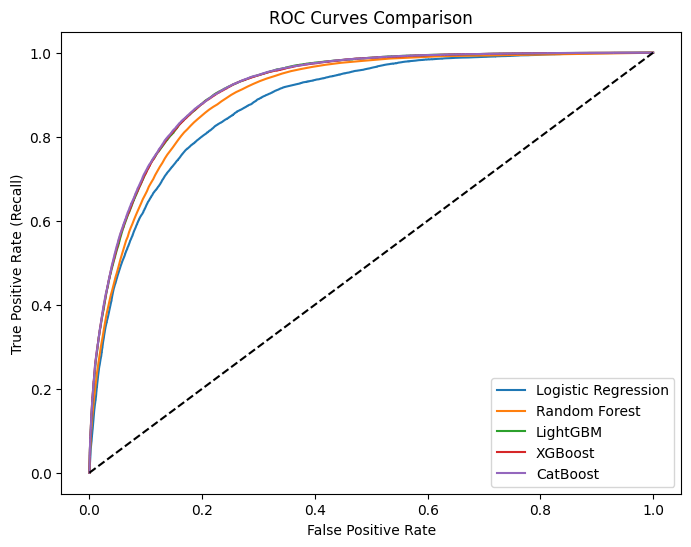

In [30]:
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_y_pred_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_y_pred_probs)
lgb_fpr, lgb_tpr, _ = roc_curve(y_val, lgb_y_pred_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_y_pred_probs)
cb_fpr, cb_tpr, _ = roc_curve(y_val, cb_y_pred_probs)

plt.figure(figsize = (8, 6))
plt.plot(lr_fpr, lr_tpr, label = "Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label = "Random Forest")
plt.plot(lgb_fpr, lgb_tpr, label = "LightGBM")
plt.plot(xgb_fpr, xgb_tpr, label = "XGBoost")
plt.plot(cb_fpr, cb_tpr, label = "CatBoost")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

## Feature Importance / Interpretability

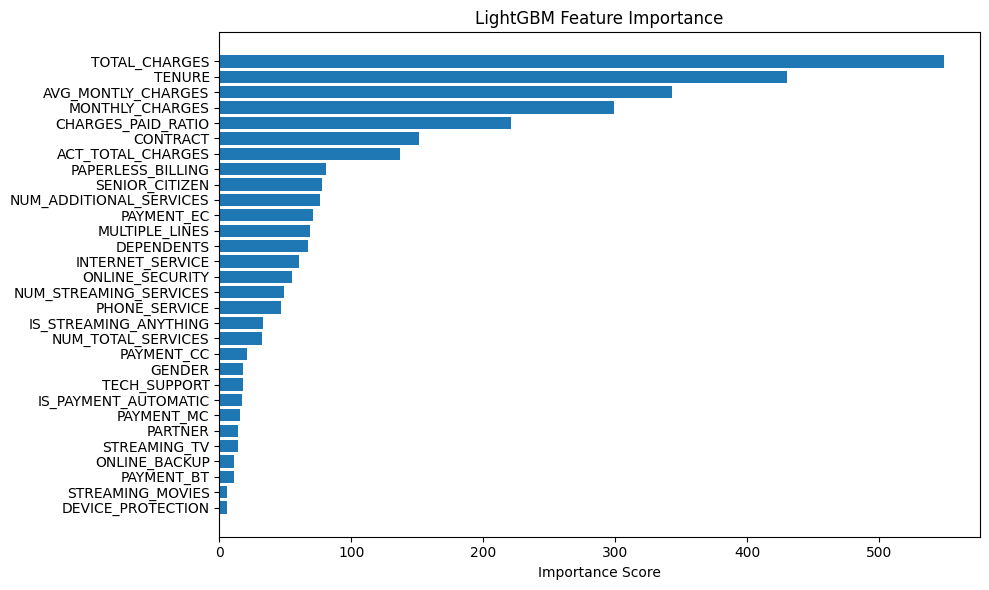

In [31]:
feature_names = X_train.columns.tolist()
importance_scores = lgb_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending = False)

plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

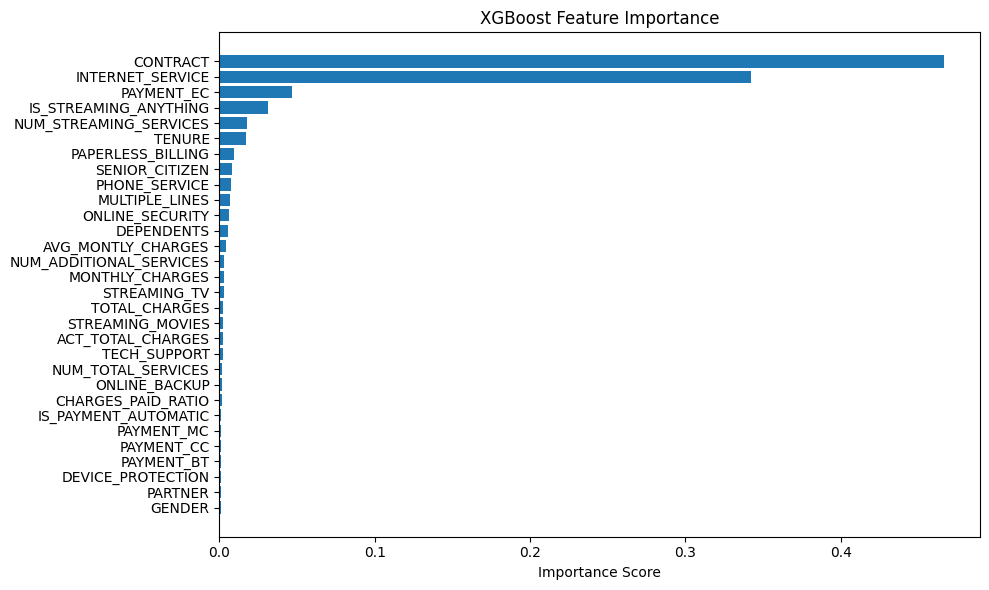

In [32]:
feature_names = X_train.columns.tolist()
importance_scores = xgb_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending = False)

plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

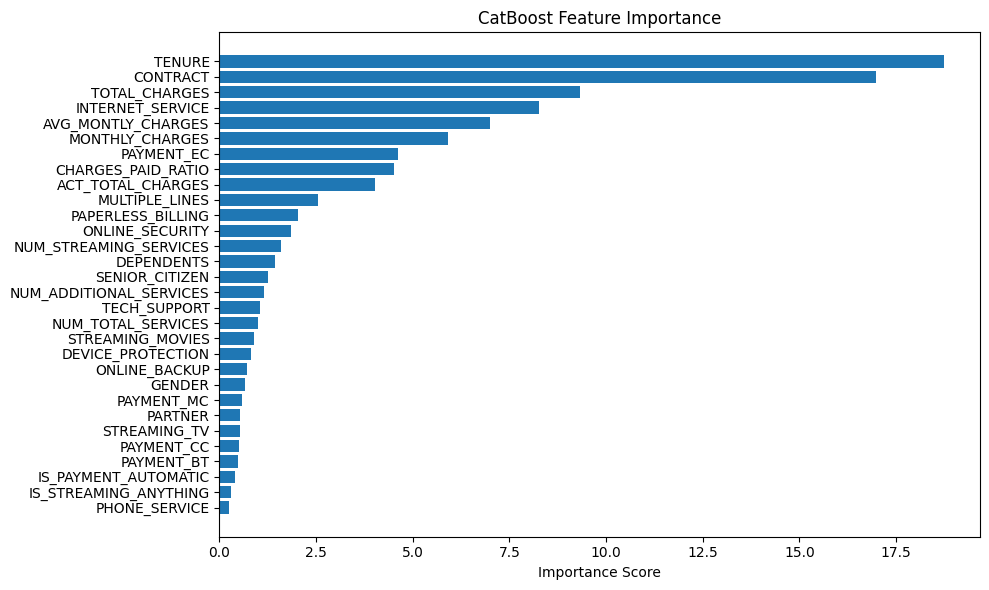

In [33]:
feature_names = X_train.columns.tolist()
importance_scores = cb_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending = False)

plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## HyperParameter Tuning

In [44]:
def get_params(trial, model_name):
    if model_name == 'lgb':
        return {
            'model__n_estimators':      trial.suggest_categorical('n_estimators', [500, 700, 900]),
            'model__max_depth':         trial.suggest_int('max_depth', 1, 7),
            'model__learning_rate':     trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
            'model__subsample':         trial.suggest_float('subsample', 0.6, 1.0, step = 0.1),
            'model__colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0, step = 0.1),
            'model__min_child_samples': trial.suggest_categorical('min_child_samples', [5, 10, 20, 30, 50]),
            'model__num_leaves':        trial.suggest_categorical('num_leaves', [15, 31, 63, 127]),
        }
    elif model_name == 'xgb':
        return {
            'model__n_estimators':        trial.suggest_categorical('n_estimators', [500, 700, 900]),
            'model__max_depth':           trial.suggest_categorical('max_depth', [1, 3, 5, 7]),
            'model__learning_rate':       trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
            'model__subsample':           trial.suggest_float('subsample', 0.6, 1.0, step = 0.1),
            'model__colsample_bytree':    trial.suggest_float('colsample_bytree', 0.6, 1.0, step = 0.1),
            'model__min_child_weight':    trial.suggest_categorical('min_child_weight', [1, 3, 5, 7]),
            'model__gamma':               trial.suggest_categorical('gamma', [0, 0.1, 0.2, 0.3]),
        }
    elif model_name == 'cb':
        return {
            'model__iterations':          trial.suggest_categorical('iterations', [500, 700, 900]),
            'model__depth':               trial.suggest_int('depth', 1, 7),
            'model__learning_rate':       trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
            'model__l2_leaf_reg':         trial.suggest_categorical('l2_leaf_reg', [1, 3, 5, 7, 9]),
            'model__subsample':           trial.suggest_float('subsample', 0.6, 1.0, step = 0.1),
            'model__colsample_bylevel':   trial.suggest_float('colsample_bylevel', 0.6, 1.0, step = 0.1),
        }
    else:
        raise ValueError(f"Unsupported model: {model_name}")

def make_objective(base_model, model_name, X, y, cv = 3):
    def objective(trial):
        params = get_params(trial, model_name)
        model = clone(base_model)
        model.set_params(**params)
        skf = StratifiedKFold(n_splits = cv, shuffle = True, random_state = 42)
        scores = cross_val_score(model, X, y, cv = skf, scoring = 'roc_auc', n_jobs = 1)
        return scores.mean()
    return objective


def run_study(base_model, model_name, X, y, n_trials = 50, cv = 3):
    study = optuna.create_study(
        direction = 'maximize',
        sampler = TPESampler(seed = 42),
        study_name = model_name
    )
    study.optimize(
        make_objective(base_model, model_name, X, y, cv),
        n_trials = n_trials,
        n_jobs = -1,
        show_progress_bar = True
    )
    print(f"\n[{model_name.upper()}] Best Parameters: {study.best_params}")
    print(f"[{model_name.upper()}] Best ROC-AUC:    {study.best_value:.4f}")
    return study

In [ ]:
models = {
    'lgb': lgb_model,
    'xgb': xgb_model,
    'cb': cb_model
}

studies = {}
for name, model in models.items():
    print(f"\nTuning {name.upper()}...")
    studies[name] = run_study(model, name, X_full, y_full, n_trials = 30)

# Access best params per model
best_params = {name: study.best_params for name, study in studies.items()}
best_scores = {name: study.best_value  for name, study in studies.items()}


Tuning LGB...


Best trial: 11. Best value: 0.916044: 100%|████████████████████████████████████████████| 30/30 [05:40<00:00, 11.34s/it]



[LGB] Best Parameters: {'n_estimators': 900, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.9, 'min_child_samples': 30, 'num_leaves': 15}
[LGB] Best ROC-AUC:    0.9160

Tuning XGB...


Best trial: 15. Best value: 0.916118: 100%|████████████████████████████████████████████| 30/30 [06:30<00:00, 13.01s/it]



[XGB] Best Parameters: {'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0.2}
[XGB] Best ROC-AUC:    0.9161

Tuning CB...


  0%|                                                                                           | 0/30 [00:00<?, ?it/s]

In [36]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# Build best models first
lgb_best = clone(lgb_model)
lgb_best.set_params(**{f'model__{k}': v for k, v in best_params['lgb'].items()})

xgb_best = clone(xgb_model)
xgb_best.set_params(**{f'model__{k}': v for k, v in best_params['xgb'].items()})

cb_best = clone(cb_model)
cb_best.set_params(**{f'model__{k}': v for k, v in best_params['cb'].items()})

# Generate OOF predictions
oof_lgb = cross_val_predict(lgb_best, X_full, y_full, cv = skf, method = 'predict_proba')[:, 1]
oof_xgb = cross_val_predict(xgb_best, X_full, y_full, cv = skf, method = 'predict_proba')[:, 1]
oof_cb  = cross_val_predict(cb_best,  X_full, y_full, cv = skf, method = 'predict_proba')[:, 1]

print(roc_auc_score(y_full, oof_lgb))
print(roc_auc_score(y_full, oof_xgb))
print(roc_auc_score(y_full, oof_cb))

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## Final Model Selection
- Both XGBoost and LightGBM were tuned using Optuna with ROC-AUC as the scoring metric.
- An ensemble of both models was created by averaging predicted probabilities.
- The ensemble achieves higher ROC-AUC than either model individually, and is therefore selected for final training and submission.

## Final Model Training

In [37]:
X_test = preprocess_and_engineer_Feature(test_df)

In [38]:
seeds = [42, 123, 456, 789, 2024]

lgb_preds = []
xgb_preds = []
cb_preds  = []

for seed in seeds:
    print(f"Seed: {seed}")
    # LGB
    _lgb = clone(lgb_model)
    _lgb.set_params(**{f'model__{k}': v for k, v in best_params['lgb'].items()})
    _lgb.set_params(model__random_state = seed)
    print("Training LGB")
    _lgb.fit(X_full, y_full)
    lgb_preds.append(_lgb.predict_proba(X_test)[:, 1])
    
    # XGB
    _xgb = clone(xgb_model)
    _xgb.set_params(**{f'model__{k}': v for k, v in best_params['xgb'].items()})
    _xgb.set_params(model__random_state = seed)
    print("Training XGB")
    _xgb.fit(X_full, y_full)
    xgb_preds.append(_xgb.predict_proba(X_test)[:, 1])

    # CB
    _cb = clone(cb_model)
    _cb.set_params(**{f'model__{k}': v for k, v in best_params['cb'].items()})
    _cb.set_params(model__random_state = seed)
    print("Training CatBoost")
    _cb.fit(X_full, y_full)
    cb_preds.append(_cb.predict_proba(X_test)[:, 1])

Seed: 42
Training LGB
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [39]:
def optimize_weights(trial):
    w_lgb = trial.suggest_float('w_lgb', 0.1, 0.8)
    w_xgb = trial.suggest_float('w_xgb', 0.1, 0.8)
    w_cb  = 1 - w_lgb - w_xgb
    
    blended = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cb * oof_cb
    return roc_auc_score(y_full, blended)

weight_study = optuna.create_study(direction = 'maximize')
weight_study.optimize(optimize_weights, n_trials = 1000, show_progress_bar = True)

print(f"Best weights: {weight_study.best_params}")
print(f"Best OOF AUC: {weight_study.best_value:.6f}")

Best trial: 620. Best value: 0.916472: 100%|███████████████████████████████████████| 1000/1000 [03:16<00:00,  5.10it/s]

Best weights: {'w_lgb': 0.36751950957829116, 'w_xgb': 0.3251362803350028}
Best OOF AUC: 0.916472


In [40]:
# Average across seeds per model
pred_lgb = np.mean(lgb_preds, axis = 0)
pred_xgb = np.mean(xgb_preds, axis = 0)
pred_cb  = np.mean(cb_preds,  axis = 0)

# Ensemble
w_lgb = weight_study.best_params['w_lgb']
w_xgb = weight_study.best_params['w_xgb']
w_cb  = 1 - w_lgb - w_xgb
print(f"w_lgb: {w_lgb:.4f}, w_xgb: {w_xgb:.4f}, w_cb: {w_cb:.4f}")

final_pred = w_lgb * pred_lgb + w_xgb * pred_xgb + w_cb * pred_cb

w_lgb: 0.3675, w_xgb: 0.3251, w_cb: 0.3073


## Submission Generation

In [41]:
submission_df = pd.DataFrame(
    {
        "id": test_df["id"],
        "Churn": final_pred
    }
)

submission_df.to_csv("../Submission/Actual_Submission.csv", index = False)

In [42]:
end_time = datetime.datetime.now()
print(f"Time taken: {end_time - start_time}")

Time taken: 0:56:34.278251
